In [30]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor


In [2]:
results_df = pd.read_parquet('rmse_summary.parquet')

In [3]:
results_df

,lead,xgb,persistence
0,1,0.019723,0.018475
1,2,0.024994,0.023287
2,3,0.030261,0.028356
3,4,0.035185,0.033724
4,5,0.038987,0.038484
5,6,0.042736,0.043070
6,7,0.045483,0.047097


In [28]:
features = (
    ["sla_now"]
    + [f"sla_lag{i}" for i in range(1,15)]
    + [
        "tmp_surface",
        "tmp_2m",
        "ugrd",
        "vgrd",
        "dswrf",
        "uswrf",
        "dlwrf",
        "ulwrf",
        "spfh",
        "prate",
        "month",
        "dayofyear",
        "latitude",
        "longitude"
    ]
)

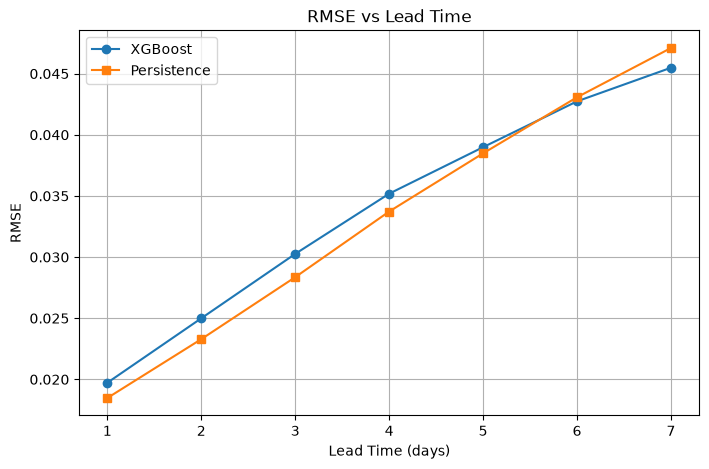

In [4]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["lead"],
    results_df["xgb"],
    marker="o",
    label="XGBoost"
)

plt.plot(
    results_df["lead"],
    results_df["persistence"],
    marker="s",
    label="Persistence"
)

plt.xlabel("Lead Time (days)")
plt.ylabel("RMSE")
plt.title("RMSE vs Lead Time")
plt.xticks(results_df["lead"])
plt.grid(True)
plt.legend()

plt.show()

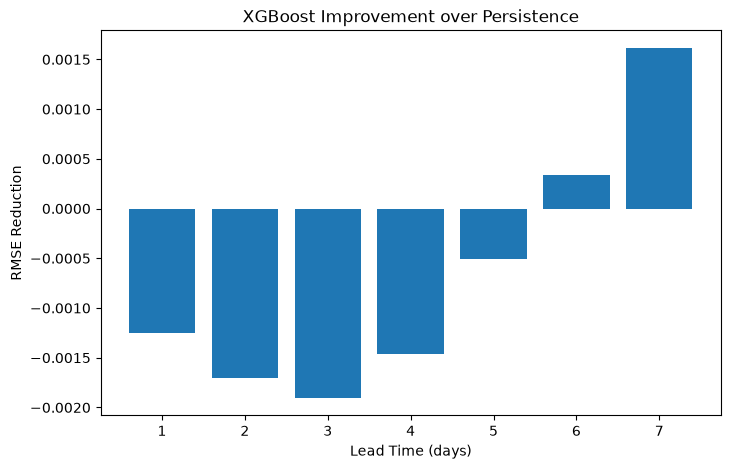

In [5]:
results_df["improvement"] = (
    results_df["persistence"] - results_df["xgb"]
)

plt.figure(figsize=(8,5))

plt.bar(
    results_df["lead"],
    results_df["improvement"]
)

plt.xlabel("Lead Time (days)")
plt.ylabel("RMSE Reduction")
plt.title("XGBoost Improvement over Persistence")

plt.show()

In [6]:
pred_dfs = {}

for lead in range(1, 8):
    pred_dfs[lead] = pd.read_parquet(
        f"pred_lead/predictions_lead_{lead}.parquet"
    )

In [8]:
pred_dfs[1].columns

Index(['time', 'latitude', 'longitude', 'truth', 'xgb', 'pers', 'err_xgb',
       'err_pers'],
      dtype='str')

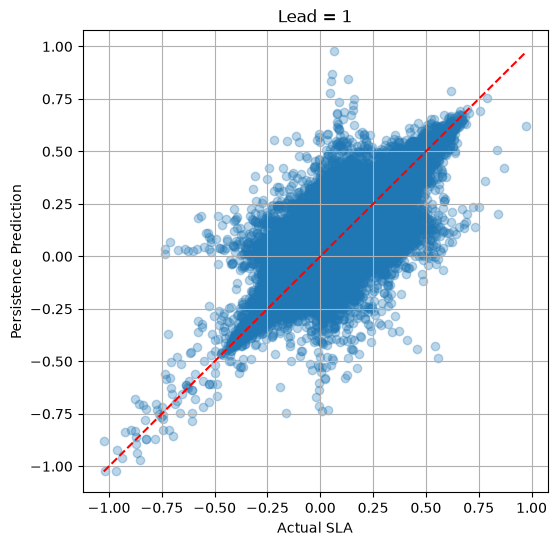

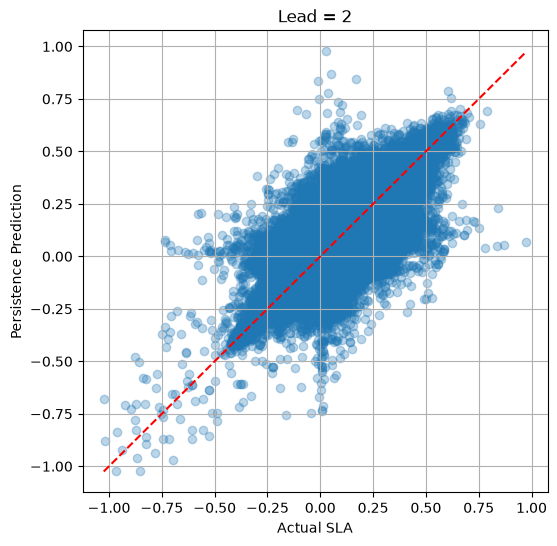

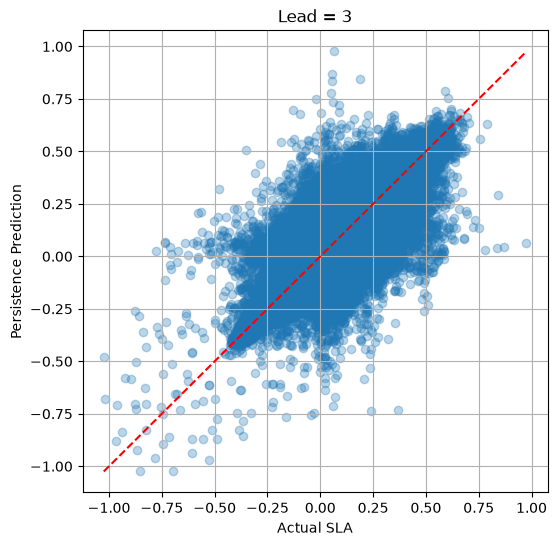

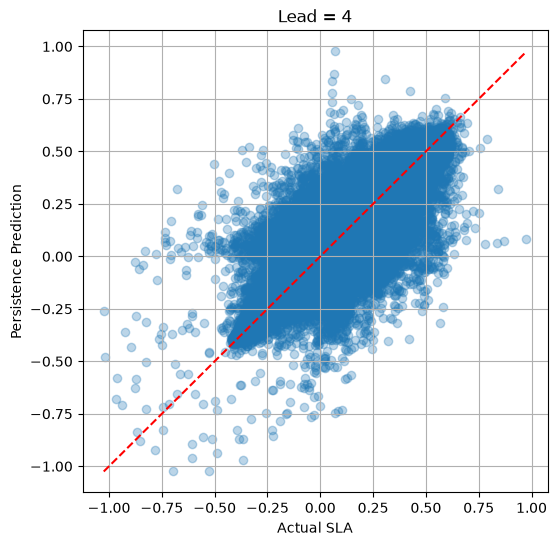

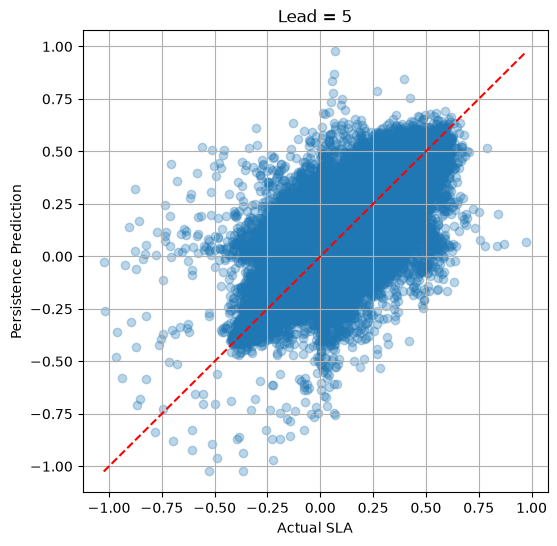

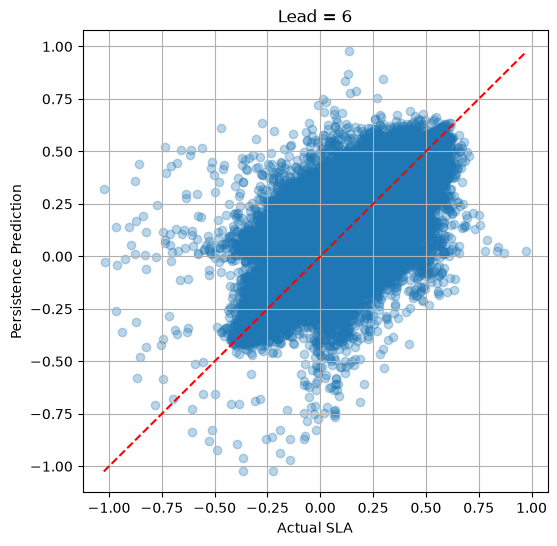

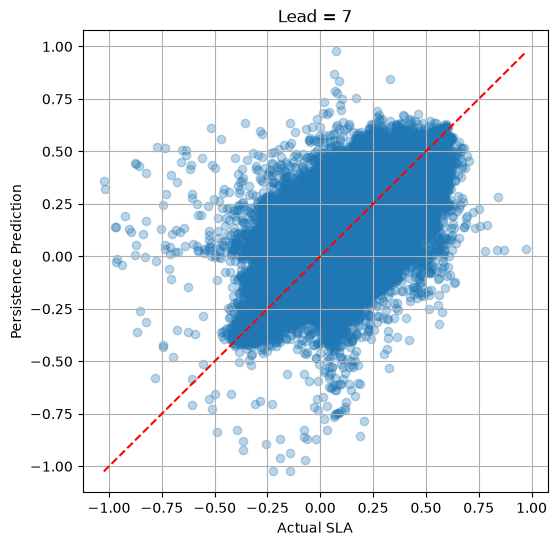

In [12]:
for lead, df in pred_dfs.items():

    plt.figure(figsize=(6,6))

    plt.scatter(df["truth"], df["pers"], alpha=0.3)

    mn = min(df["truth"].min(), df["pers"].min())
    mx = max(df["truth"].max(), df["pers"].max())

    plt.plot([mn,mx], [mn,mx], 'r--')

    plt.xlabel("Actual SLA")
    plt.ylabel("Persistence Prediction")
    plt.title(f"Lead = {lead}")
    plt.grid(True)

    plt.show()

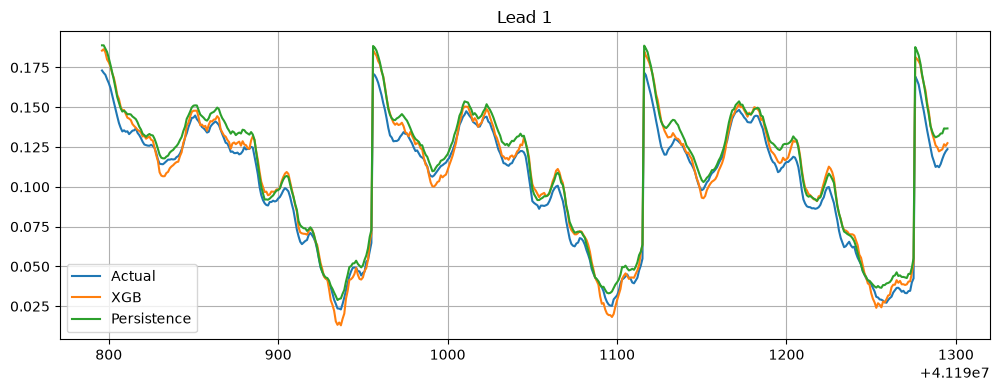

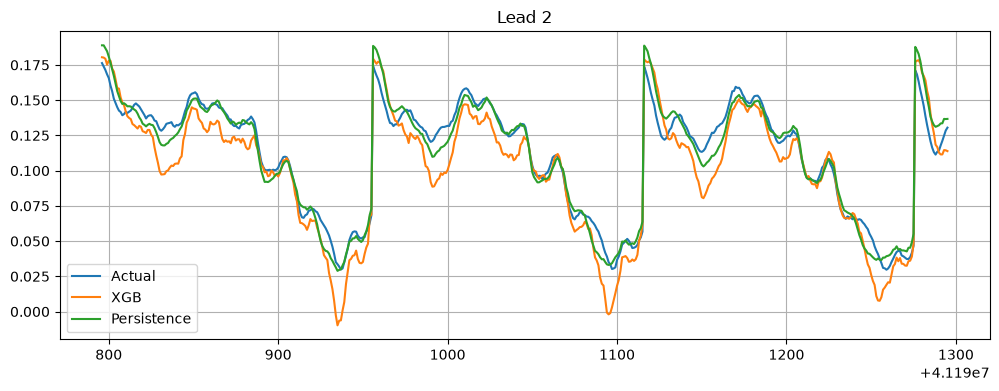

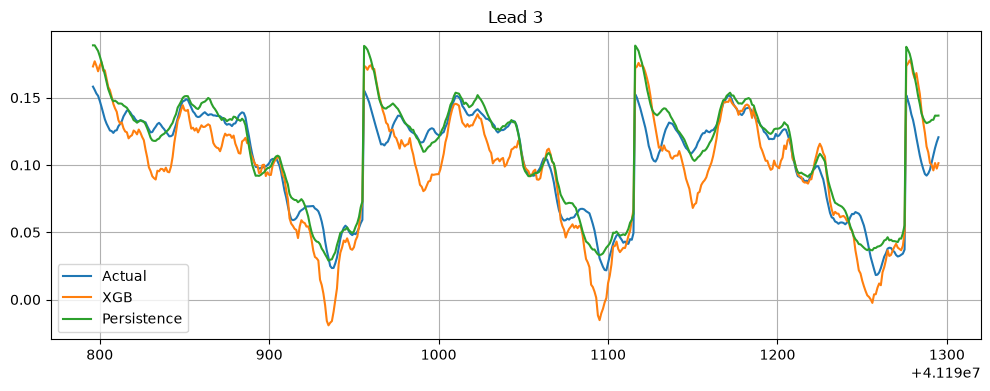

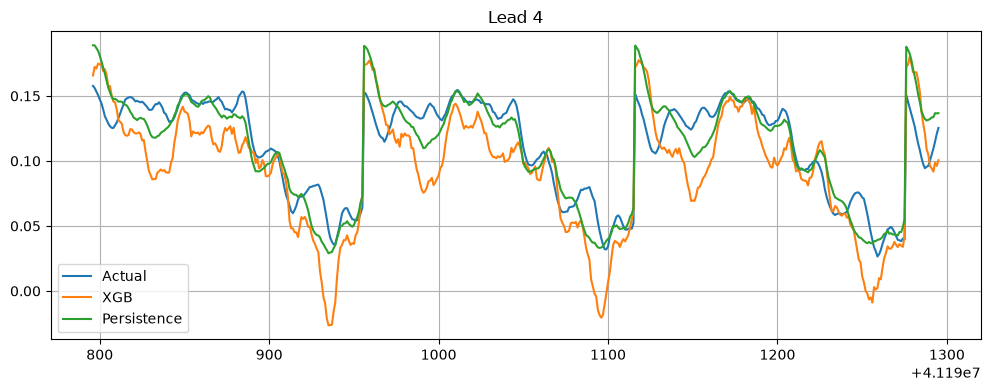

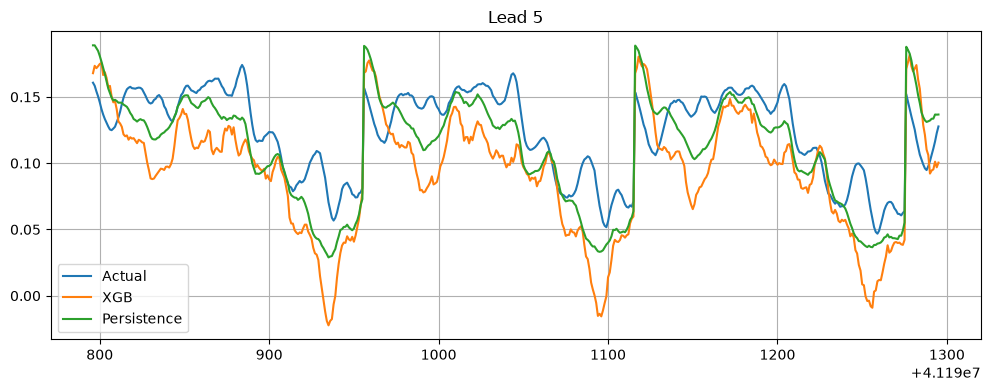

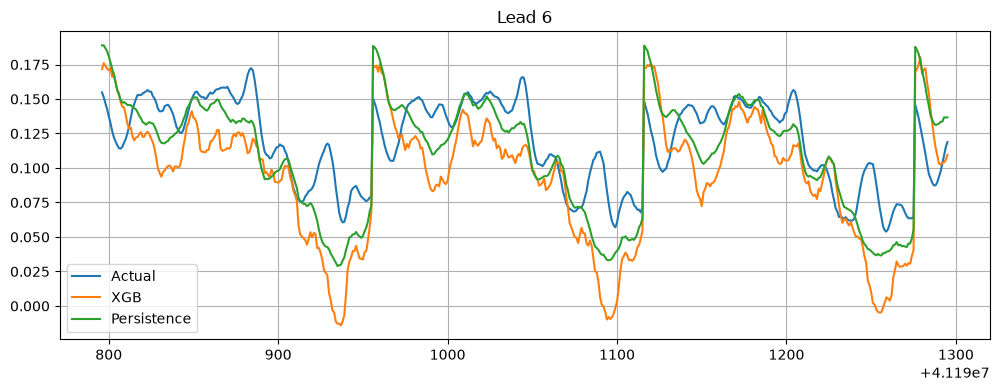

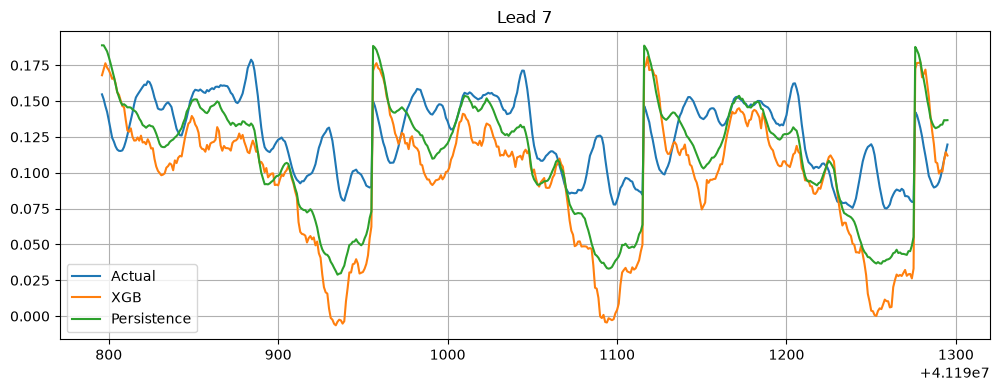

In [14]:
for lead, df in pred_dfs.items():

    plt.figure(figsize=(12,4))

    plt.plot(df["truth"].iloc[:500], label="Actual")
    plt.plot(df["xgb"].iloc[:500], label="XGB")
    plt.plot(df["pers"].iloc[:500], label="Persistence")

    plt.title(f"Lead {lead}")
    plt.legend()
    plt.grid(True)

    plt.show()

In [35]:
lead1 = xr.open_dataset('improv_leadnc/improvement_lead_1.nc')

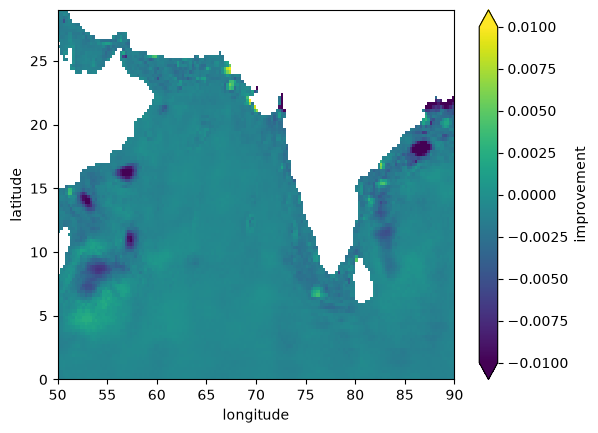

In [37]:
lead1.improvement.plot(vmin=-0.01,vmax=0.01)

In [49]:
lead1.improvement.isel(lead1.improvement.argmax(dim=["latitude","longitude"])).coords

Coordinates:
    latitude   float32 4B 21.88
    longitude  float32 4B 69.38

In [67]:
best = lead1.improvement.stack(
    point=("latitude", "longitude")
).idxmax()

In [74]:
print(best)

<xarray.DataArray 'point' ()> Size: 8B
array((21.875, 69.375), dtype=object)


In [92]:
lead1.improvement.isel(latitude=slice(18,20),longitude=slice(10,15))

<xarray.DataArray 'improvement' (latitude: 2, longitude: 5)> Size: 40B
[10 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 8B 4.625 4.875
  * longitude  (longitude) float32 20B 52.62 52.88 53.12 53.38 53.62

In [100]:
lead1.improvement.sel(latitude=4.625,longitude=52.88,method="nearest")


<xarray.DataArray 'improvement' ()> Size: 4B
[1 values with dtype=float32]
Coordinates:
    latitude   float32 4B 4.625
    longitude  float32 4B 52.88

In [ ]:
df = pred_dfs[1]

In [101]:
point = df[
    (df["latitude"] == 4.625) &
    (df["longitude"] == 52.875)
    ].sort_values("time")

In [102]:
point

,time,latitude,longitude,truth,xgb,pers,err_xgb,err_pers
41193687,2024-01-01,4.625,52.875,-0.031700,-0.016655,-0.019000,0.015045,0.012700
41205781,2024-01-02,4.625,52.875,-0.030000,-0.032701,-0.031700,-0.002701,-0.001700
41217875,2024-01-03,4.625,52.875,-0.042000,-0.031604,-0.030000,0.010396,0.012000
41229969,2024-01-04,4.625,52.875,-0.044900,-0.044297,-0.042000,0.000603,0.002900
41242063,2024-01-05,4.625,52.875,-0.040500,-0.046673,-0.044900,-0.006173,-0.004400
...,...,...,...,...,...,...,...,...
49070520,2025-09-30,4.625,52.875,-0.193200,-0.179176,-0.177375,0.014024,0.015825
49082894,2025-10-01,4.625,52.875,-0.181425,-0.212209,-0.193200,-0.030784,-0.011775
49095268,2025-10-02,4.625,52.875,-0.161725,-0.214269,-0.181425,-0.052544,-0.019700
49107642,2025-10-03,4.625,52.875,-0.137700,-0.146407,-0.161725,-0.008707,-0.024025


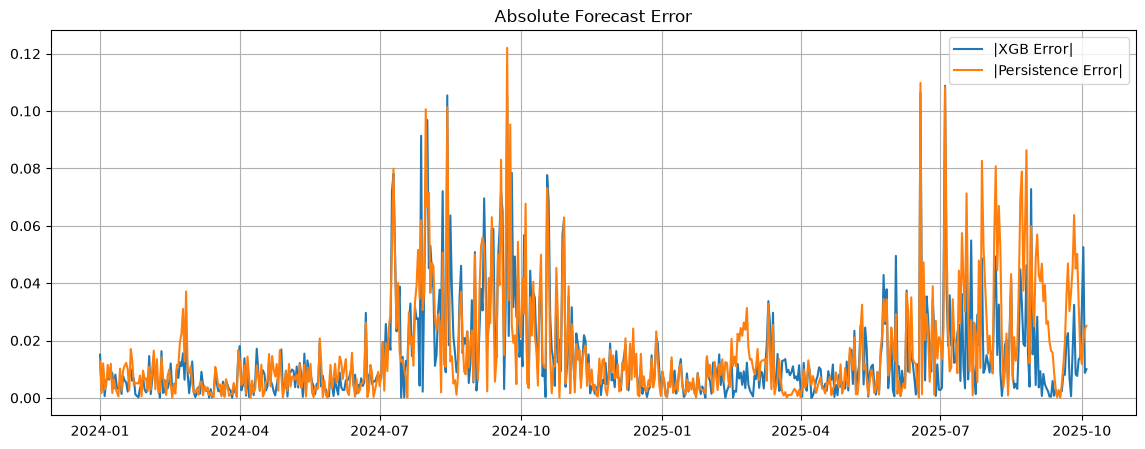

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    point["time"],
    np.abs(point["err_xgb"]),
    label="|XGB Error|"
)

plt.plot(
    point["time"],
    np.abs(point["err_pers"]),
    label="|Persistence Error|"
)

plt.legend()
plt.grid(True)
plt.title("Absolute Forecast Error")
plt.show()

In [105]:
rmse_xgb = np.sqrt((point["err_xgb"]**2).mean())
rmse_pers = np.sqrt((point["err_pers"]**2).mean())

print(rmse_xgb, rmse_pers)

0.022089588 0.02463845


In [110]:
lat = 4.625
lon = 52.875

point_results = []

for lead, df in pred_dfs.items():

    point = df[
        (df["latitude"] == lat) &
        (df["longitude"] == lon)
    ]

    rmse_xgb = np.sqrt((point["err_xgb"]**2).mean())
    rmse_pers = np.sqrt((point["err_pers"]**2).mean())

    point_results.append({
        "lead": lead,
        "xgb": rmse_xgb,
        "persistence": rmse_pers
    })

point_results = pd.DataFrame(point_results)

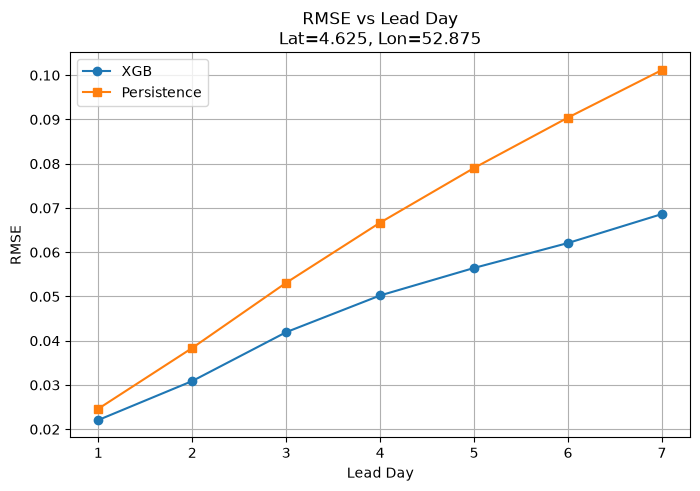

In [112]:
plt.figure(figsize=(8,5))

plt.plot(
    point_results["lead"],
    point_results["xgb"],
    marker="o",
    label="XGB"
)

plt.plot(
    point_results["lead"],
    point_results["persistence"],
    marker="s",
    label="Persistence"
)

plt.xlabel("Lead Day")
plt.ylabel("RMSE")
plt.title(
    f"RMSE vs Lead Day\nLat={lat}, Lon={lon}"
)

plt.grid(True)
plt.legend()
plt.show()

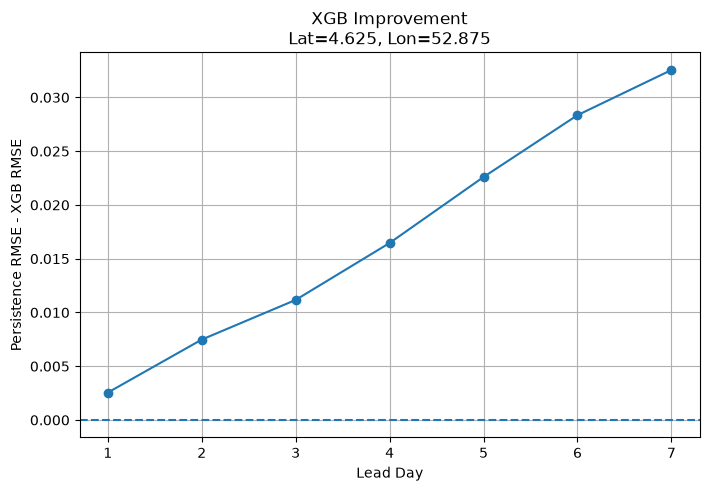

In [114]:
point_results["improvement"] = (
    point_results["persistence"]
    - point_results["xgb"]
)

plt.figure(figsize=(8,5))

plt.plot(
    point_results["lead"],
    point_results["improvement"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Lead Day")
plt.ylabel("Persistence RMSE - XGB RMSE")
plt.title(
    f"XGB Improvement\nLat={lat}, Lon={lon}"
)

plt.grid(True)
plt.show()

In [32]:
importance_df = pd.DataFrame(index=features)
for lead in range(1, 8):

    model = XGBRegressor()
    model.load_model(f"model_info/xgb_lead_{lead}.json")

    fi = pd.Series(
        model.feature_importances_,
        index=features,
        name=f"lead_{lead}"
    )

    importance_df[f"lead_{lead}"] = fi

importance_df

,lead_1,lead_2,lead_3,lead_4,lead_5,lead_6,lead_7
sla_now,0.760679,0.737901,0.700515,0.667491,0.628818,0.596903,0.571797
sla_lag1,0.117068,0.118875,0.114331,0.112669,0.117354,0.124336,0.125417
sla_lag2,0.091235,0.093016,0.106874,0.114478,0.121778,0.122375,0.126397
sla_lag3,0.013829,0.021040,0.030131,0.035778,0.040880,0.044413,0.046860
sla_lag4,0.002571,0.005740,0.009367,0.012084,0.013668,0.013858,0.014222
sla_lag5,0.006755,0.007735,0.008602,0.009648,0.010520,0.011712,0.013006
sla_lag6,0.000450,0.001073,0.001629,0.002617,0.003543,0.004050,0.004511
sla_lag7,0.000390,0.001268,0.002736,0.003636,0.005254,0.005363,0.005687
sla_lag8,0.000615,0.001928,0.003288,0.005387,0.005787,0.008362,0.009252
sla_lag9,0.000519,0.001253,0.002927,0.003680,0.004883,0.006325,0.005931
